In [ ]:
#Import necessary Libraries

In [1]:
import tensorflow as tf
from tensorflow import keras
from keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import models, layers

In [ ]:
#Data Pre-processing of the images

In [2]:
dataflow = ImageDataGenerator(rescale = 1.0 / 255.0 )

In [ ]:
#Fetch the training set of images  along with their associated one-hot encoded labels

In [3]:
train = dataflow.flow_from_directory('/content/drive/MyDrive/Colab Notebooks/data/train', class_mode = 'categorical')

Found 40 images belonging to 2 classes.


In [ ]:
#Fetch the testing set of images  along with their associated one-hot encoded labels

In [4]:
test = dataflow.flow_from_directory('/content/drive/MyDrive/Colab Notebooks/data/test', class_mode = 'categorical')

Found 20 images belonging to 2 classes.


In [ ]:
'''The CNN model would have the following layers:
● Input layer
● Convolutional layer 1 with 32 filters of kernel size[5,5]
● Pooling layer 1 with pool size[2,2] and stride 2
● Convolutional layer 2 with 64 filters of kernel size[5,5]
● Pooling layer 2 with pool size[2,2] and stride 2
● Dense layer whose output size is fixed in the hyper parameter: fc_size=32
● Dropout layer with dropout probability 0.4
Predict the class by doing a softmax on the output of the dropout layers.
'''

In [5]:
model = models.Sequential()
model.add( layers.Conv2D( 32, (5, 5 ), activation = 'relu', padding = 'same', input_shape = (256,  256 , 3 )))
model.add(layers.MaxPooling2D(2,2))
model.add(layers.Conv2D(64, (5, 5 ), activation = 'relu'))
model.add(layers.MaxPooling2D((2,2)))
model.add(layers.Dropout(0.4))
model.add(layers.Flatten())
model.add(layers.Dense(32, activation = 'relu'))
model.add(layers.Dense(2, activation = 'softmax'))


In [ ]:
#SGD Optimizer with learning rate 0.001 is used to define and the loss function

In [6]:
sgd_optimizer = tf.keras.optimizers.SGD(learning_rate = 0.001)

In [ ]:
#Compiling the model

In [7]:
history=model.compile( optimizer = sgd_optimizer, loss = 'binary_crossentropy', metrics =  ['accuracy'])

In [ ]:
#Model training for 100 iterations

In [8]:
history = model.fit(train, validation_data = test, epochs =100)

Epoch 1/100
2/2 [==============================] - 18s 5s/step - loss: 0.6957 - accuracy: 0.5000 - val_loss: 0.6955 - val_accuracy: 0.4500
Epoch 2/100
2/2 [==============================] - 0s 154ms/step - loss: 0.6897 - accuracy: 0.5250 - val_loss: 0.7005 - val_accuracy: 0.5000
Epoch 3/100
2/2 [==============================] - 0s 154ms/step - loss: 0.6910 - accuracy: 0.5000 - val_loss: 0.6977 - val_accuracy: 0.5000
Epoch 4/100
2/2 [==============================] - 0s 161ms/step - loss: 0.6973 - accuracy: 0.5500 - val_loss: 0.6966 - val_accuracy: 0.5000
Epoch 5/100
2/2 [==============================] - 0s 319ms/step - loss: 0.6909 - accuracy: 0.5500 - val_loss: 0.6983 - val_accuracy: 0.5000
Epoch 6/100
2/2 [==============================] - 0s 157ms/step - loss: 0.6910 - accuracy: 0.5750 - val_loss: 0.6952 - val_accuracy: 0.5000
Epoch 7/100
2/2 [==============================] - 0s 153ms/step - loss: 0.6805 - accuracy: 0.6750 - val_loss: 0.6951 - val_accuracy: 0.5000
Epoch 8/100
2/2

In [9]:
test_loss, test_accuracy = model.evaluate(test)

1/1 [==============================] - 0s 131ms/step - loss: 0.7281 - accuracy: 0.4500


In [10]:
print(test_loss)

0.7281455993652344


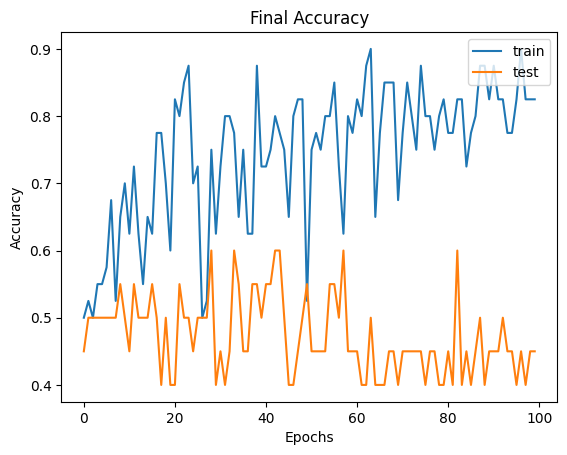

In [11]:
from matplotlib import pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Final Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epochs')
plt.legend(['train', 'test'], loc = 'upper right')
plt.show()

In [ ]:
#Model training for 200 iterations

In [12]:
history = model.fit(train, validation_data = test, epochs =200)

Epoch 1/200
2/2 [==============================] - 1s 512ms/step - loss: 0.4307 - accuracy: 0.8750 - val_loss: 0.7277 - val_accuracy: 0.4500
Epoch 2/200
2/2 [==============================] - 0s 162ms/step - loss: 0.4257 - accuracy: 0.8500 - val_loss: 0.7266 - val_accuracy: 0.4500
Epoch 3/200
2/2 [==============================] - 1s 429ms/step - loss: 0.4330 - accuracy: 0.8750 - val_loss: 0.7326 - val_accuracy: 0.4500
Epoch 4/200
2/2 [==============================] - 0s 202ms/step - loss: 0.4406 - accuracy: 0.8500 - val_loss: 0.8251 - val_accuracy: 0.6000
Epoch 5/200
2/2 [==============================] - 0s 339ms/step - loss: 0.4574 - accuracy: 0.7750 - val_loss: 0.7321 - val_accuracy: 0.4500
Epoch 6/200
2/2 [==============================] - 0s 307ms/step - loss: 0.4305 - accuracy: 0.8250 - val_loss: 0.7366 - val_accuracy: 0.4500
Epoch 7/200
2/2 [==============================] - 0s 141ms/step - loss: 0.4099 - accuracy: 0.8250 - val_loss: 0.7771 - val_accuracy: 0.4500
Epoch 8/200
2

In [13]:
test_loss, test_accuracy = model.evaluate(test)

1/1 [==============================] - 0s 115ms/step - loss: 1.0633 - accuracy: 0.5500


In [14]:
print(test_loss)

1.0632596015930176


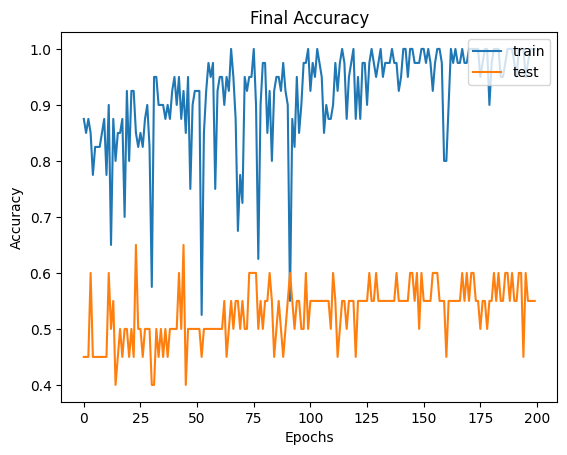

In [15]:
from matplotlib import pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Final Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epochs')
plt.legend(['train', 'test'], loc = 'upper right')
plt.show()

In [ ]:
#Model Training for 300 iterations

In [16]:
history = model.fit(train, validation_data = test, epochs =300)

Epoch 1/300
2/2 [==============================] - 1s 249ms/step - loss: 0.0793 - accuracy: 1.0000 - val_loss: 1.0323 - val_accuracy: 0.5500
Epoch 2/300
2/2 [==============================] - 0s 311ms/step - loss: 0.0886 - accuracy: 1.0000 - val_loss: 1.0223 - val_accuracy: 0.6000
Epoch 3/300
2/2 [==============================] - 0s 148ms/step - loss: 0.0699 - accuracy: 0.9750 - val_loss: 1.0100 - val_accuracy: 0.5000
Epoch 4/300
2/2 [==============================] - 0s 141ms/step - loss: 0.0669 - accuracy: 1.0000 - val_loss: 1.0511 - val_accuracy: 0.5500
Epoch 5/300
2/2 [==============================] - 0s 150ms/step - loss: 0.0604 - accuracy: 1.0000 - val_loss: 1.0203 - val_accuracy: 0.6000
Epoch 6/300
2/2 [==============================] - 0s 143ms/step - loss: 0.0702 - accuracy: 1.0000 - val_loss: 1.0868 - val_accuracy: 0.5500
Epoch 7/300
2/2 [==============================] - 0s 315ms/step - loss: 0.0623 - accuracy: 1.0000 - val_loss: 1.0127 - val_accuracy: 0.6000
Epoch 8/300
2

In [17]:
test_loss, test_accuracy = model.evaluate(test)

1/1 [==============================] - 0s 117ms/step - loss: 1.4812 - accuracy: 0.6000


In [18]:
print(test_loss)

1.4812219142913818


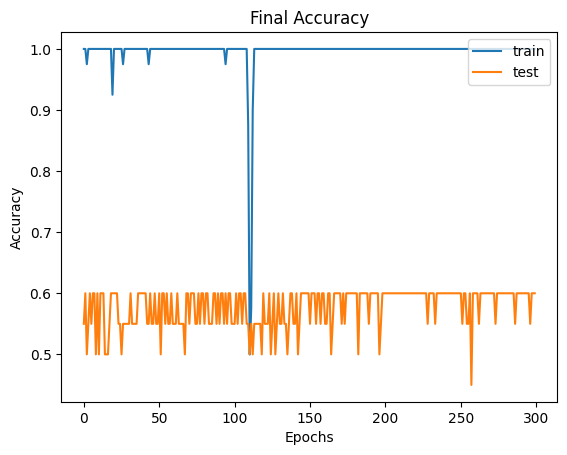

In [19]:
from matplotlib import pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Final Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epochs')
plt.legend(['train', 'test'], loc = 'upper right')
plt.show()